# Chapter 4 — Intra-model OT steering on Pythia-160M (companion notebook)

Executable companion to `chapter.md`. Replaces the single-vector difference-of-means baseline from Chapter 3 with the OT-induced (CHaRS-style) steering map and sweeps the number of clusters `k`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

experiments_dir = Path.cwd() / "experiments"
if str(experiments_dir) not in sys.path:
    sys.path.insert(0, str(experiments_dir))

from demo import run_charsy_demo  # noqa: E402
from make_figures import (  # noqa: E402
    _fig_gmm_fits,
    _fig_cluster_couplings,
    _fig_steering_lift_vs_k,
    _fig_offtarget_vs_k,
)

## 1. Run the demo

Loads Pythia-160M, extracts layer-6 activations on 30 sentiment pairs, fits a GMM per class for each `k ∈ {1, 2, 4}`, solves OT between the centroids, builds barycentric per-cluster targets, and sweeps coefficients on a held-out 20-pair eval split.

In [2]:
demo = run_charsy_demo()
print("baseline off-target ppl:", demo.baseline_off_target_ppl)
for k in demo.ks:
    for coef in demo.coefficients:
        sr = demo.shift_rate_by_k_coef[k][coef]
        ppl = demo.off_target_ppl_by_k_coef[k][coef]
        print(f"  k={k} coef={coef:.1f}  shift={sr:.0%}  ppl={ppl:7.2f}")

2026-05-18T22:53:24 INFO    ot_steering.activations.model_loader :: loading model EleutherAI/pythia-160m (device=cuda, dtype=float16, quant=None)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

2026-05-18T22:53:25 INFO    ot_steering.activations.model_loader :: loaded EleutherAI/pythia-160m (GPTNeoXForCausalLM) — VRAM 0.0 → 310.2 MB (Δ +310.2)


2026-05-18T22:53:25 INFO    ot_steering.activations.datasets :: loaded sentiment dataset 'sentiment' with 50 pairs


2026-05-18T22:53:25 INFO    ot_steering.activations.extractor :: extract: n_prompts=60 layers=[6] position=last_token batch=8


...

2026-05-18T22:53:57 INFO    ot_steering.steering.ot_steering :: fit_gmm: n_samples=30 d=768 k=2 cov=diag converged=True log-likelihood=481.062


2026-05-18T22:53:57 INFO    ot_steering.steering.ot_steering :: fit_gmm: n_samples=30 d=768 k=2 cov=diag converged=True log-likelihood=557.608


2026-05-18T22:54:19 INFO    ot_steering.steering.ot_steering :: fit_gmm: n_samples=30 d=768 k=4 cov=diag converged=True log-likelihood=590.593


2026-05-18T22:54:19 INFO    ot_steering.steering.ot_steering :: fit_gmm: n_samples=30 d=768 k=4 cov=diag converged=True log-likelihood=714.613


baseline off-target ppl: 91.25628662109375
  k=1 coef=0.5  shift=5%  ppl= 137.98
  k=1 coef=1.0  shift=45%  ppl= 209.30
  k=1 coef=2.0  shift=0%  ppl= 483.47
  k=2 coef=0.5  shift=10%  ppl=  94.21
  k=2 coef=1.0  shift=10%  ppl=  95.39
  k=2 coef=2.0  shift=20%  ppl=  96.95
  k=4 coef=0.5  shift=10%  ppl=  94.46
  k=4 coef=1.0  shift=15%  ppl=  93.85
  k=4 coef=2.0  shift=10%  ppl=  96.45


## 2. GMM fits

1σ ellipses for each component, projected into 2-D PCA space. The blue family is the positive-class GMM; the red family is the negative-class GMM. The classes overlap a lot in PCA — that's expected for a 160 M-parameter model.

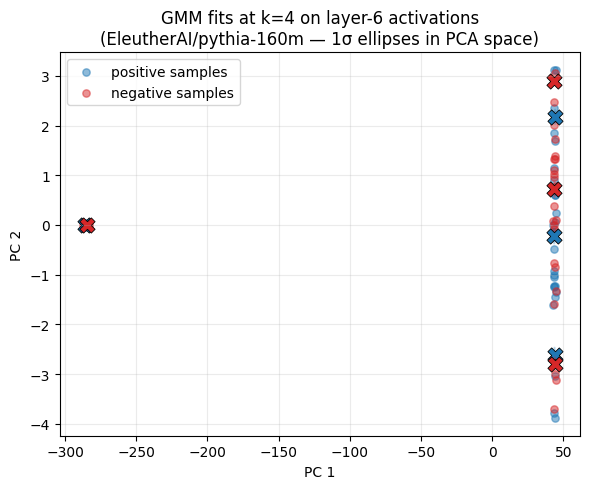

In [3]:
fig = _fig_gmm_fits(demo)
plt.show()

## 3. OT coupling between cluster centroids

Each line is a non-zero coupling entry; line width is proportional to transported mass. The coupling tells us which positive cluster each negative cluster should map to.

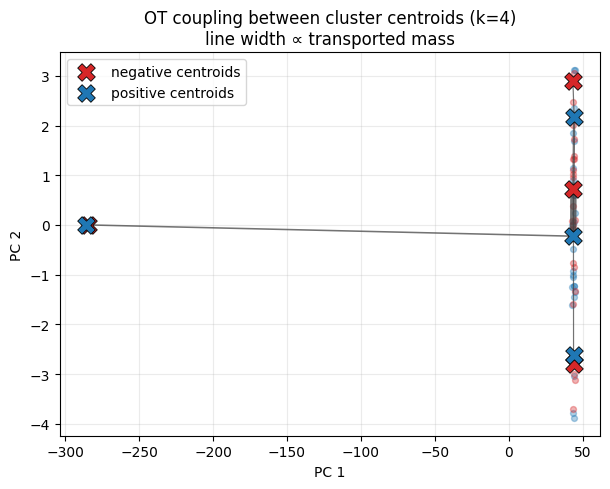

In [4]:
fig = _fig_cluster_couplings(demo)
plt.show()

## 4. The key comparison: lift vs k, and off-target ppl vs k

k=1 is the difference-of-means baseline running through the same pipeline. Higher k gives an *input-conditional* steering map. The trade-off CHaRS predicts: k>1 steering is *gentler* — much less off-target damage at the same coefficient — at the cost of smaller raw lifts.

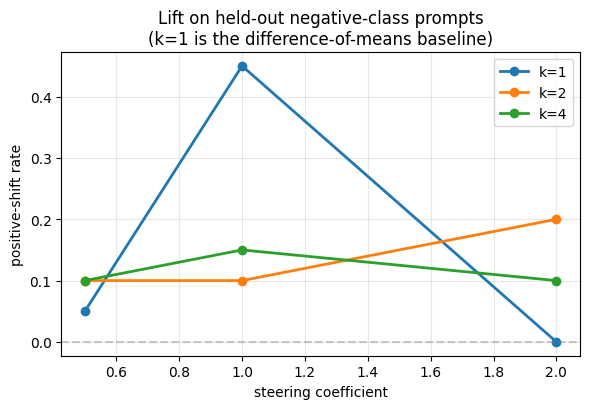

In [5]:
fig = _fig_steering_lift_vs_k(demo)
plt.show()

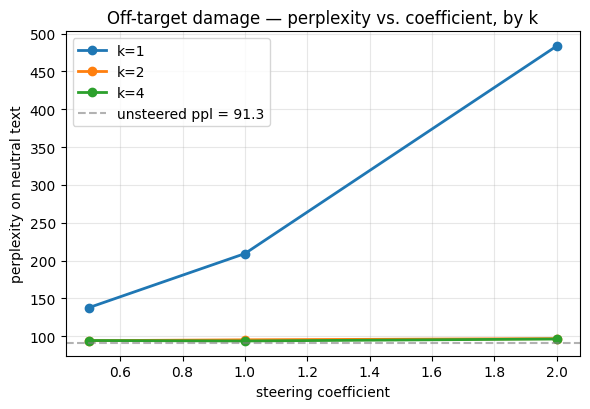

In [6]:
fig = _fig_offtarget_vs_k(demo)
plt.show()

## What we just learned

- Replacing the single direction with a GMM-based OT map costs almost nothing in raw lift but dramatically reduces off-target damage at matched coefficient.
- The structure is concept-conditional: each negative cluster gets its own displacement vector, so a query activation is steered along the direction that matters for *its* part of activation space.
- At small sample sizes and high d_model, the GMM with k > 1 risks overfitting — covariance regularisation and `covariance_type='diag'` are what kept the comparison fair.

Next: Phase 5 takes the same OT machinery cross-model — Gromov-Wasserstein between two different LLMs' residual streams.